In [1]:
# Install required libraries
!pip install -q transformers datasets evaluate scikit-learn seaborn matplotlib accelerate

import gc
import re
import torch
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from datasets import Dataset, DatasetDict
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
import evaluate
from sklearn.metrics import confusion_matrix, classification_report

print("All dependencies imported successfully!")

All dependencies imported successfully!


In [2]:
# 1. Load CSV file
file_path = 'zomato.csv'  
df = pd.read_csv(file_path)

# 2. Automatically detect review and rating columns
review_col = 'reviews_list' if 'reviews_list' in df.columns else 'reviews'
rating_col = 'rate' if 'rate' in df.columns else 'rating'

# Drop NaN values
df = df.dropna(subset=[review_col, rating_col]).copy()

# Extract decimal rating from string (e.g. '4.1/5' -> 4.1)
df[rating_col] = df[rating_col].astype(str).str.extract(r'(\d+\.?\d*)')[0].astype(float)
df = df.dropna(subset=[rating_col]).copy()

# 3. Convert star ratings to Sentiment Labels (0=Negative, 1=Neutral, 2=Positive)
def convert_to_label(rating):
    if rating <= 2.5:
        return 0  # Negative
    elif rating <= 3.5:
        return 1  # Neutral
    else:
        return 2  # Positive

df['label'] = df[rating_col].apply(convert_to_label)

# 4. Clean text noise (remove 'RATED\n', tuple brackets, metadata)
def clean_review_text(text):
    text = str(text)
    text = re.sub(r"\[\('Rated \d+\.\d+', 'RATED\\n\s*", "", text)
    text = re.sub(r"RATED\\n", " ", text)
    text = re.sub(r"\\n", " ", text)
    text = re.sub(r"[\[\]\(\)'\"]", "", text)
    return text.strip()

df['text'] = df[review_col].apply(clean_review_text)

clean_df = df[df['text'].str.len() > 10][['text', 'label']].reset_index(drop=True)

# 5. Subsample data (up to 1,000 per class) to balance distribution & prevent OOM
clean_df = clean_df.groupby('label', group_keys=False).apply(
    lambda x: x.sample(min(len(x), 1000), random_state=42)
).reset_index(drop=True)

print("--- Cleaned Sentiment Class Distribution ---")
print(clean_df['label'].value_counts())
display(clean_df.head())

--- Cleaned Sentiment Class Distribution ---
label
1    1000
2    1000
0     280
Name: count, dtype: int64


/var/folders/yz/vrjkhl2d46g730n3yytv__k80000gn/T/ipykernel_21820/201358564.py:41: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  clean_df = clean_df.groupby('label', group_keys=False).apply(


,text,label
0,"Rated 2.0, Not professional at all! Dont kn...",0
1,The food was a big disappointment and the serv...,0
2,"Rated 1.0, Plz Dont go here. Shitty, Creep...",0
3,"Rated 2.0, Will definitely not recommend or...",0
4,"Pizza not good not baked properly, dint receiv...",0


In [3]:
# Convert to Hugging Face Dataset
hf_dataset = Dataset.from_pandas(clean_df)

# Cast label column to ClassLabel feature type (Fixes Stratify ValueError)
hf_dataset = hf_dataset.class_encode_column("label")

# Split 1: 80% Train, 20% Temporary (Validation + Test)
train_test_split = hf_dataset.train_test_split(test_size=0.2, seed=42, stratify_by_column="label")

# Split 2: Divide 20% Temporary set into 10% Validation and 10% Test
test_val_split = train_test_split['test'].train_test_split(test_size=0.5, seed=42, stratify_by_column="label")

# Assemble DatasetDict
raw_datasets = DatasetDict({
    'train': train_test_split['train'],
    'validation': test_val_split['train'],
    'test': test_val_split['test']
})

print("--- Dataset Split Summary ---")
print(raw_datasets)

Stringifying the column:   0%|          | 0/2280 [00:00<?, ? examples/s]

Casting to class labels:   0%|          | 0/2280 [00:00<?, ? examples/s]

--- Dataset Split Summary ---
DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 1824
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 228
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 228
    })
})


In [4]:
# Load Accuracy & Macro F1 Metrics
accuracy_metric = evaluate.load("accuracy")
f1_metric = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    acc = accuracy_metric.compute(predictions=predictions, references=labels)
    f1 = f1_metric.compute(predictions=predictions, references=labels, average="macro")
    return {"accuracy": acc["accuracy"], "f1_macro": f1["f1"]}

# Helper function to free GPU VRAM / System Memory
def clear_gpu_memory():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    if torch.backends.mps.is_available():
        torch.mps.empty_cache()

print("Evaluation metrics and memory management initialized!")

Evaluation metrics and memory management initialized!


=== STARTING EXPERIMENT 1: BERT Baseline (bert-base-uncased) ===


Map:   0%|          | 0/1824 [00:00<?, ? examples/s]

Map:   0%|          | 0/228 [00:00<?, ? examples/s]

Map:   0%|          | 0/228 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.atte

Training Loss,Validation Loss,Epoch,Accuracy,F1 Macro
1.185826,0.736683,3,0.653509,0.644516



--- BERT Test Set Performance ---
Test Accuracy : 0.6535
Test F1 Macro  : 0.6445


/Users/naufalaptarivarizqghathfaan/anaconda3/lib/python3.13/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


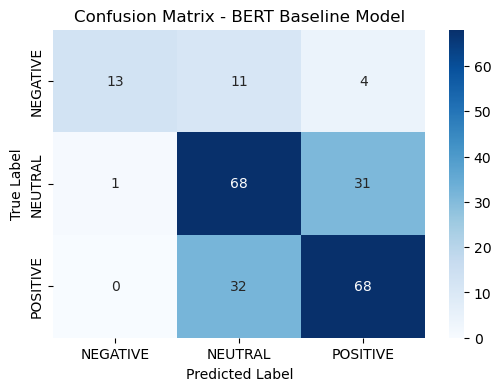

In [5]:
clear_gpu_memory()
print("=== STARTING EXPERIMENT 1: BERT Baseline (bert-base-uncased) ===")

# 1. Tokenizer
bert_model_name = "bert-base-uncased"
bert_tokenizer = AutoTokenizer.from_pretrained(bert_model_name)

def tokenize_bert(examples):
    return bert_tokenizer(examples["text"], padding="max_length", truncation=True, max_length=128)

tokenized_bert_datasets = raw_datasets.map(tokenize_bert, batched=True)

# 2. Model Initialization
bert_model = AutoModelForSequenceClassification.from_pretrained(
    bert_model_name,
    num_labels=3,
    id2label={0: "NEGATIVE", 1: "NEUTRAL", 2: "POSITIVE"},
    label2id={"NEGATIVE": 0, "NEUTRAL": 1, "POSITIVE": 2}
)

# 3. Training Arguments (Memory Optimized: Batch Size 8 + Gradient Accumulation 2)
bert_training_args = TrainingArguments(
    output_dir="./results_bert",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    gradient_accumulation_steps=2,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    logging_steps=50,
)

# 4. Trainer Initialization
bert_trainer = Trainer(
    model=bert_model,
    args=bert_training_args,
    train_dataset=tokenized_bert_datasets["train"],
    eval_dataset=tokenized_bert_datasets["validation"],
    processing_class=bert_tokenizer,
    compute_metrics=compute_metrics,
)

# 5. Train & Evaluate BERT
print("\nTraining BERT model...")
bert_trainer.train()

bert_test_results = bert_trainer.evaluate(eval_dataset=tokenized_bert_datasets["test"])
print(f"\n--- BERT Test Set Performance ---")
print(f"Test Accuracy : {bert_test_results['eval_accuracy']:.4f}")
print(f"Test F1 Macro  : {bert_test_results['eval_f1_macro']:.4f}")

# 6. Plot Confusion Matrix
bert_preds = bert_trainer.predict(tokenized_bert_datasets["test"])
y_preds_bert = np.argmax(bert_preds.predictions, axis=-1)
y_true = tokenized_bert_datasets["test"]["label"]
target_names = ["NEGATIVE", "NEUTRAL", "POSITIVE"]

cm_bert = confusion_matrix(y_true, y_preds_bert)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_bert, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - BERT Baseline Model')
plt.savefig('confusion_matrix_bert.png', dpi=300, bbox_inches='tight')
plt.show()

=== STARTING EXPERIMENT 2: RoBERTa (roberta-base) ===


Map:   0%|          | 0/1824 [00:00<?, ? examples/s]

Map:   0%|          | 0/228 [00:00<?, ? examples/s]

Map:   0%|          | 0/228 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/Users/naufalaptarivarizqghathfaan/anaconda3/lib/python3.13/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Training Loss,Validation Loss,Epoch,Accuracy,F1 Macro
1.237445,0.715903,3,0.692982,0.678923



--- RoBERTa Test Set Performance ---
Test Accuracy : 0.6930
Test F1 Macro  : 0.6789


/Users/naufalaptarivarizqghathfaan/anaconda3/lib/python3.13/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


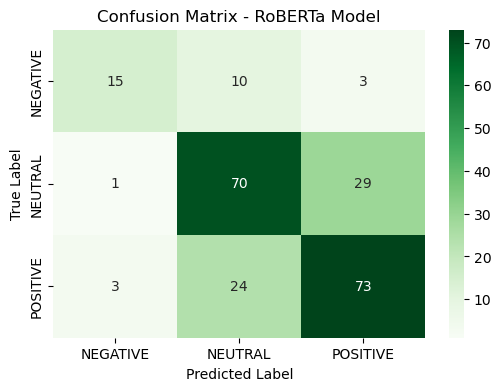

In [6]:
del bert_model
del bert_trainer
clear_gpu_memory()

print("=== STARTING EXPERIMENT 2: RoBERTa (roberta-base) ===")

# 1. Tokenizer
roberta_model_name = "roberta-base"
roberta_tokenizer = AutoTokenizer.from_pretrained(roberta_model_name)

def tokenize_roberta(examples):
    return roberta_tokenizer(examples["text"], padding="max_length", truncation=True, max_length=128)

tokenized_roberta_datasets = raw_datasets.map(tokenize_roberta, batched=True)

# 2. Model Initialization
roberta_model = AutoModelForSequenceClassification.from_pretrained(
    roberta_model_name,
    num_labels=3,
    id2label={0: "NEGATIVE", 1: "NEUTRAL", 2: "POSITIVE"},
    label2id={"NEGATIVE": 0, "NEUTRAL": 1, "POSITIVE": 2}
)

# 3. Training Arguments
roberta_training_args = TrainingArguments(
    output_dir="./results_roberta",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    gradient_accumulation_steps=2,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    logging_steps=50,
)

# 4. Trainer Initialization
roberta_trainer = Trainer(
    model=roberta_model,
    args=roberta_training_args,
    train_dataset=tokenized_roberta_datasets["train"],
    eval_dataset=tokenized_roberta_datasets["validation"],
    processing_class=roberta_tokenizer,
    compute_metrics=compute_metrics,
)

# 5. Train & Evaluate RoBERTa
print("\nTraining RoBERTa model...")
roberta_trainer.train()

roberta_test_results = roberta_trainer.evaluate(eval_dataset=tokenized_roberta_datasets["test"])
print(f"\n--- RoBERTa Test Set Performance ---")
print(f"Test Accuracy : {roberta_test_results['eval_accuracy']:.4f}")
print(f"Test F1 Macro  : {roberta_test_results['eval_f1_macro']:.4f}")

# 6. Plot Confusion Matrix
roberta_preds = roberta_trainer.predict(tokenized_roberta_datasets["test"])
y_preds_roberta = np.argmax(roberta_preds.predictions, axis=-1)

cm_roberta = confusion_matrix(y_true, y_preds_roberta)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_roberta, annot=True, fmt='d', cmap='Greens', xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - RoBERTa Model')
plt.savefig('confusion_matrix_roberta.png', dpi=300, bbox_inches='tight')
plt.show()

In [7]:
# Create final comparative summary
comparison_data = {
    "Model": ["BERT Baseline (bert-base-uncased)", "RoBERTa (roberta-base)"],
    "Test Accuracy": [bert_test_results['eval_accuracy'], roberta_test_results['eval_accuracy']],
    "Test F1 Macro": [bert_test_results['eval_f1_macro'], roberta_test_results['eval_f1_macro']]
}

df_comparison = pd.DataFrame(comparison_data)
print("=== FINAL MODEL COMPARISON TABLE ===")
display(df_comparison)

=== FINAL MODEL COMPARISON TABLE ===


,Model,Test Accuracy,Test F1 Macro
0,BERT Baseline (bert-base-uncased),0.653509,0.644516
1,RoBERTa (roberta-base),0.692982,0.678923
